In [12]:
import collections
from io import StringIO

import numpy as np
import pandas as pd
import pydotplus  # pip install pydotplus
import seaborn as sns
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz

from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"] = (10, 8)

In [13]:
# Create dataframe with dummy variables
def create_df(dic, feature_list):
    out = pd.DataFrame(dic)
    out = pd.concat([out, pd.get_dummies(out[feature_list])], axis=1)
    out.drop(feature_list, axis=1, inplace=True)
    return out


# Some feature values are present in train and absent in test and vice-versa.
def intersect_features(train, test):
    common_feat = list(set(train.keys()) & set(test.keys()))
    return train[common_feat], test[common_feat]

In [14]:
features = ["Looks", "Alcoholic_beverage", "Eloquence", "Money_spent"]

# Training data

In [15]:
df_train = {}
df_train["Looks"] = [
    "handsome",
    "handsome",
    "handsome",
    "repulsive",
    "repulsive",
    "repulsive",
    "handsome",
]
df_train["Alcoholic_beverage"] = ["yes", "yes", "no", "no", "yes", "yes", "yes"]
df_train["Eloquence"] = ["high", "low", "average", "average", "low", "high", "average"]
df_train["Money_spent"] = ["lots", "little", "lots", "little", "lots", "lots", "lots"]
df_train["Will_go"] = LabelEncoder().fit_transform(["+", "-", "+", "-", "-", "+", "+"])

df_train = create_df(df_train, features)
df_train

,Will_go,Looks_handsome,Looks_repulsive,Alcoholic_beverage_no,Alcoholic_beverage_yes,Eloquence_average,Eloquence_high,Eloquence_low,Money_spent_little,Money_spent_lots
0,0,True,False,False,True,False,True,False,False,True
1,1,True,False,False,True,False,False,True,True,False
2,0,True,False,True,False,True,False,False,False,True
3,1,False,True,True,False,True,False,False,True,False
4,1,False,True,False,True,False,False,True,False,True
5,0,False,True,False,True,False,True,False,False,True
6,0,True,False,False,True,True,False,False,False,True


# Test data

In [16]:
df_test = {}
df_test["Looks"] = ["handsome", "handsome", "repulsive"]
df_test["Alcoholic_beverage"] = ["no", "yes", "yes"]
df_test["Eloquence"] = ["average", "high", "average"]
df_test["Money_spent"] = ["lots", "little", "lots"]
df_test = create_df(df_test, features)
df_test

,Looks_handsome,Looks_repulsive,Alcoholic_beverage_no,Alcoholic_beverage_yes,Eloquence_average,Eloquence_high,Money_spent_little,Money_spent_lots
0,True,False,True,False,True,False,False,True
1,True,False,False,True,False,True,True,False
2,False,True,False,True,True,False,False,True


In [17]:
# Some feature values are present in train and absent in test and vice-versa.
y = df_train["Will_go"]
df_train, df_test = intersect_features(train=df_train, test=df_test)
df_train

,Alcoholic_beverage_yes,Money_spent_lots,Looks_handsome,Alcoholic_beverage_no,Eloquence_high,Looks_repulsive,Money_spent_little,Eloquence_average
0,True,True,True,False,True,False,False,False
1,True,False,True,False,False,False,True,False
2,False,True,True,True,False,False,False,True
3,False,False,False,True,False,True,True,True
4,True,True,False,False,False,True,False,False
5,True,True,False,False,True,True,False,False
6,True,True,True,False,False,False,False,True


In [18]:
df_test

,Alcoholic_beverage_yes,Money_spent_lots,Looks_handsome,Alcoholic_beverage_no,Eloquence_high,Looks_repulsive,Money_spent_little,Eloquence_average
0,False,True,True,True,False,False,False,True
1,True,False,True,False,True,False,True,False
2,True,True,False,False,False,True,False,True


Draw a decision tree (by hand or in any graphics editor) for this dataset. Optionally you can also implement tree construction and draw it here.

#### 1. What is the entropy of the initial system? By system states, we mean values of the binary feature “Will_go” - 0 or 1 - two states in total.

In [22]:
probs = y.value_counts(normalize=True).values

In [23]:
entropy = np.sum(-probs * np.log2(probs))
entropy

np.float64(0.9852281360342515)

#### 2. Let’s split the data by the feature “Looks_handsome”. What is the entropy  of the left group - the one with “Looks_handsome”. What is the entropy in the opposite group? What is the information gain (IG) if we consider such a split?

In [32]:
df_train_f = pd.concat([df_train, y], axis=1)

df_train_hands = df_train_f[df_train_f['Looks_handsome'] == True]

In [33]:
probs = df_train_hands['Will_go'].value_counts(normalize=True).values
entropy = np.sum(-probs * np.log2(probs))
entropy

np.float64(0.8112781244591328)

In [36]:
df_train_not_hands = df_train_f[df_train_f['Looks_handsome'] != True]
probs = df_train_not_hands['Will_go'].value_counts(normalize=True).values
entropy = np.sum(-probs * np.log2(probs))
entropy

np.float64(0.9182958340544896)

Признак 'Looks_handsome' не дал значительного уровня ясности влияния на y.

Train a decision tree using sklearn on the training data. You may choose any depth for the tree

In [37]:
tree = DecisionTreeClassifier(max_depth=3, random_state=88)

tree.fit(X=df_train, y=y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",88
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

Additional: display the resulting tree using graphviz. You can use pydot or a web-service, e.g. this one.

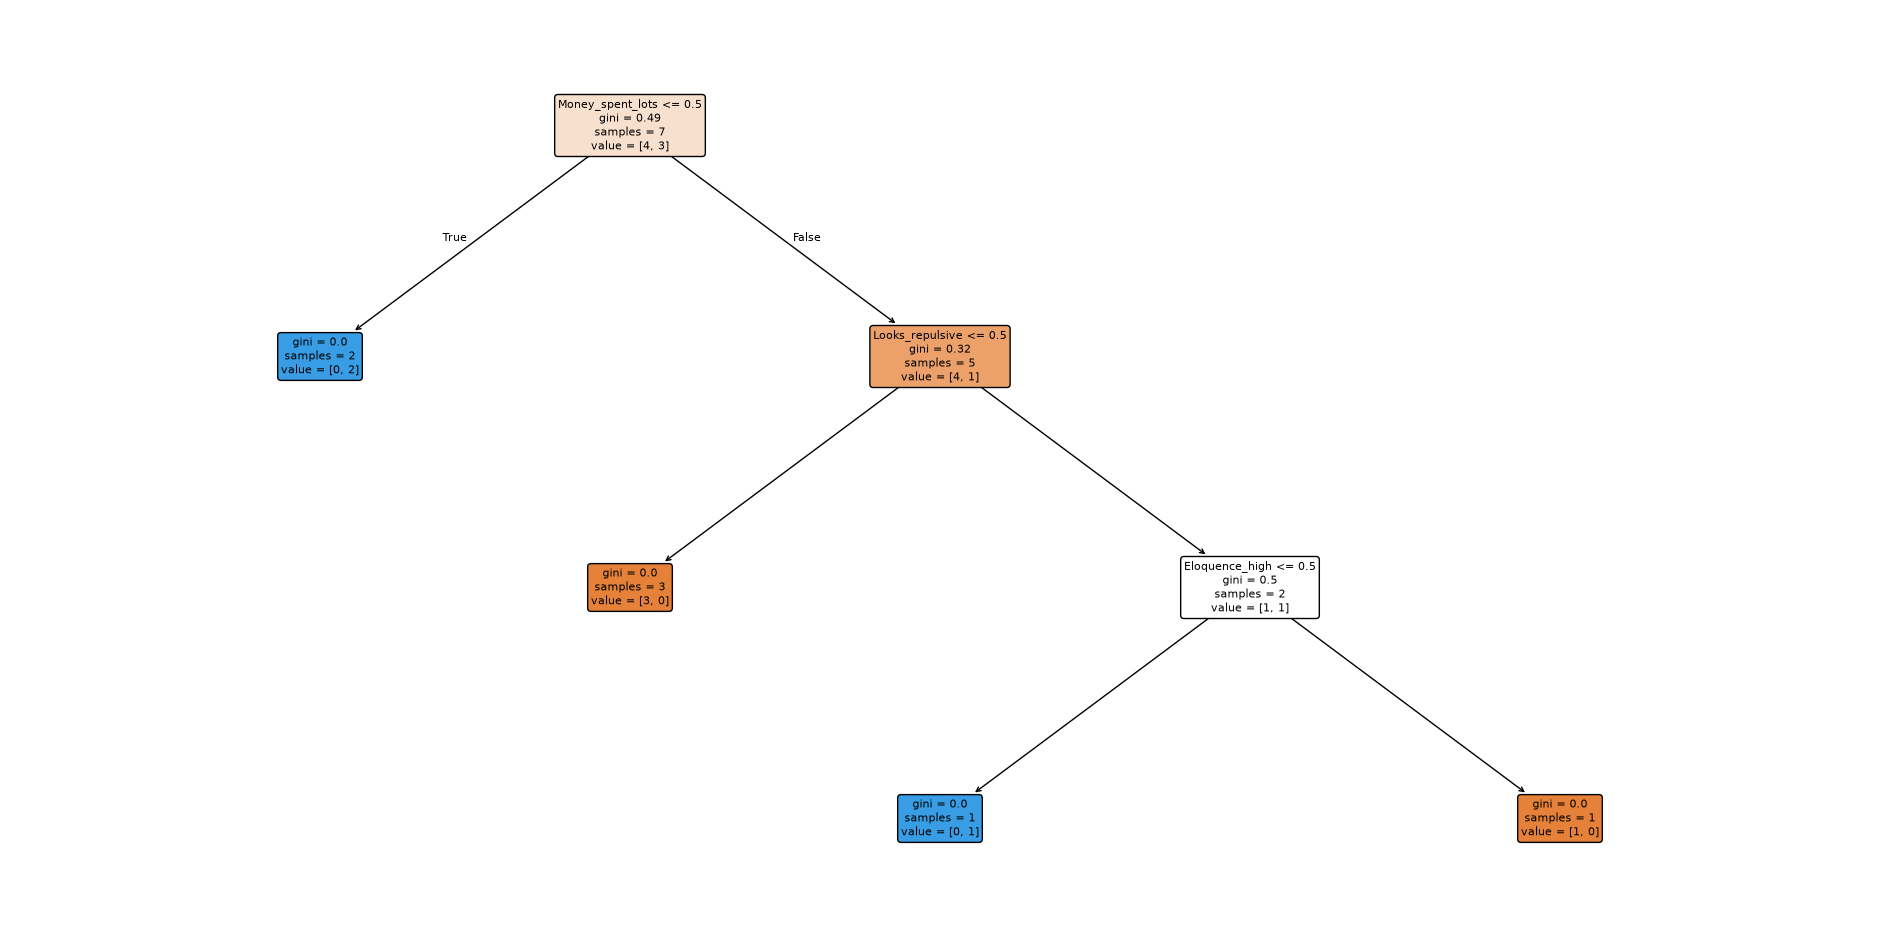

In [38]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 12))

plot_tree(
    tree,
    feature_names=df_train.columns.to_list(),
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

#### Part 2. Functions for calculating entropy and information gain.

In [39]:
balls = [1 for i in range(9)] + [0 for i in range(11)]


In [40]:
# two groups
balls_left = [1 for i in range(8)] + [0 for i in range(5)]  # 8 blue and 5 yellow
balls_right = [1 for i in range(1)] + [0 for i in range(6)]  # 1 blue and 6 yellow

#### Implement a function to calculate the Shannon Entropy

In [51]:
from collections import Counter

def entropy(a_list):
    counts = Counter(a_list)
    n = len(a_list)

    probs = np.array([count / n for count in counts.values()])

    return -np.sum(probs * np.log2(probs))

In [52]:
entropy(balls)

np.float64(0.9927744539878083)

3. What is the entropy of the state given by the list balls_left?



In [53]:
print(entropy(balls_left))

0.9612366047228759


In [54]:
print(entropy(balls_right))

0.5916727785823275


4. What is the entropy of a fair die? (where we look at a die as a system with 6 equally probable states)?

In [55]:
print(entropy([1, 2, 3, 4, 5, 6]))

2.584962500721156


In [56]:
# information gain calculation
def information_gain(root, left, right):
    
    ig = entropy(root) - (len(left)/len(root)*entropy(left) + len(right)/len(root)*entropy(right))

    return ig

5. What is the information gain from splitting the initial dataset into balls_left and balls_right ?

In [57]:
information_gain(balls, balls_left, balls_right)

np.float64(0.16088518841412436)

Implement a decision tree building algorithm by calling information_gains recursively



In [58]:
def entropy(a_list):
    """
    Считает энтропию списка классов.
    Например: [0, 0, 1, 1, 1]
    """
    counts = Counter(a_list)
    n = len(a_list)

    probs = np.array([count / n for count in counts.values()])

    return -np.sum(probs * np.log2(probs))


def information_gain(root, left, right):
    """
    Считает information gain для одного split.

    root  — классы до разбиения
    left  — классы в левой ветке
    right — классы в правой ветке
    """
    n = len(root)
    n_left = len(left)
    n_right = len(right)

    return entropy(root) - (
        n_left / n * entropy(left)
        + n_right / n * entropy(right)
    )


def information_gains(X, y):
    """
    Считает information gain для каждого признака из X.
    Подходит для бинарных признаков True/False или 0/1.
    """
    gains = {}

    for feature in X.columns:
        mask = X[feature].astype(bool)

        y_left = y[mask]
        y_right = y[~mask]

        # если split пустой с одной стороны, он бесполезен
        if len(y_left) == 0 or len(y_right) == 0:
            gains[feature] = 0
        else:
            gains[feature] = information_gain(y, y_left, y_right)

    return gains


def most_common_class(y):
    """
    Возвращает самый частый класс в текущем узле.
    Это будет prediction для листа.
    """
    return Counter(y).most_common(1)[0][0]


def build_tree(X, y, depth=0, max_depth=3):
    """
    Рекурсивно строит простое дерево решений.

    X — признаки
    y — целевая переменная
    depth — текущая глубина
    max_depth — максимальная глубина дерева
    """

    # 1. Если в узле остался только один класс — делить больше не надо
    if len(set(y)) == 1:
        return {
            "type": "leaf",
            "prediction": y.iloc[0]
        }

    # 2. Если достигли максимальной глубины — делаем лист
    if depth == max_depth:
        return {
            "type": "leaf",
            "prediction": most_common_class(y)
        }

    # 3. Если признаков больше нет — делаем лист
    if X.shape[1] == 0:
        return {
            "type": "leaf",
            "prediction": most_common_class(y)
        }

    # 4. Считаем information gain для каждого признака
    gains = information_gains(X, y)

    # 5. Выбираем признак с максимальным information gain
    best_feature = max(gains, key=gains.get)
    best_gain = gains[best_feature]

    # 6. Если лучший gain равен 0 — дальше делить бессмысленно
    if best_gain == 0:
        return {
            "type": "leaf",
            "prediction": most_common_class(y)
        }

    # 7. Делим данные по лучшему признаку
    mask = X[best_feature].astype(bool)

    X_left = X[mask].drop(columns=[best_feature])
    y_left = y[mask]

    X_right = X[~mask].drop(columns=[best_feature])
    y_right = y[~mask]

    # 8. Рекурсивно строим левую и правую ветки
    left_subtree = build_tree(X_left, y_left, depth + 1, max_depth)
    right_subtree = build_tree(X_right, y_right, depth + 1, max_depth)

    # 9. Возвращаем узел дерева
    return {
        "type": "node",
        "feature": best_feature,
        "information_gain": best_gain,
        "left": left_subtree,
        "right": right_subtree
    }

In [59]:
my_tree = build_tree(df_train, y, max_depth=3)

In [60]:
import matplotlib.pyplot as plt


def assign_positions(tree, depth=0, positions=None, leaf_counter=None):
    """
    Рекурсивно назначает каждому узлу координаты на графике.
    Листья раскладываются слева направо.
    Внутренний узел ставится посередине между своими детьми.
    """
    if positions is None:
        positions = {}

    if leaf_counter is None:
        leaf_counter = [0]

    # если это лист
    if tree["type"] == "leaf":
        x = leaf_counter[0]
        y = -depth
        positions[id(tree)] = (x, y)
        leaf_counter[0] += 1
        return positions

    # если это обычный узел, сначала размещаем детей
    assign_positions(tree["left"], depth + 1, positions, leaf_counter)
    assign_positions(tree["right"], depth + 1, positions, leaf_counter)

    # координата родителя — середина между детьми
    x_left, _ = positions[id(tree["left"])]
    x_right, _ = positions[id(tree["right"])]

    x = (x_left + x_right) / 2
    y = -depth

    positions[id(tree)] = (x, y)

    return positions


def draw_tree_node(tree, positions, ax):
    """
    Рисует один узел дерева и рекурсивно рисует его детей.
    """
    x, y = positions[id(tree)]

    # текст внутри узла
    if tree["type"] == "leaf":
        label = f"Predict: {tree['prediction']}"
        box_style = "round,pad=0.4"
    else:
        label = f"{tree['feature']}\nIG={tree['information_gain']:.3f}"
        box_style = "round,pad=0.4"

    # рисуем сам узел
    ax.text(
        x,
        y,
        label,
        ha="center",
        va="center",
        bbox=dict(boxstyle=box_style, facecolor="white", edgecolor="black")
    )

    # если это лист — детей нет
    if tree["type"] == "leaf":
        return

    # координаты детей
    x_left, y_left = positions[id(tree["left"])]
    x_right, y_right = positions[id(tree["right"])]

    # линии к детям
    ax.plot([x, x_left], [y, y_left], color="black")
    ax.plot([x, x_right], [y, y_right], color="black")

    # подписи веток
    ax.text((x + x_left) / 2, (y + y_left) / 2, "True", ha="right")
    ax.text((x + x_right) / 2, (y + y_right) / 2, "False", ha="left")

    # рекурсивно рисуем детей
    draw_tree_node(tree["left"], positions, ax)
    draw_tree_node(tree["right"], positions, ax)


def plot_custom_tree(tree):
    """
    Главная функция для отрисовки дерева.
    """
    positions = assign_positions(tree)

    fig, ax = plt.subplots(figsize=(14, 8))

    draw_tree_node(tree, positions, ax)

    ax.axis("off")
    plt.show()

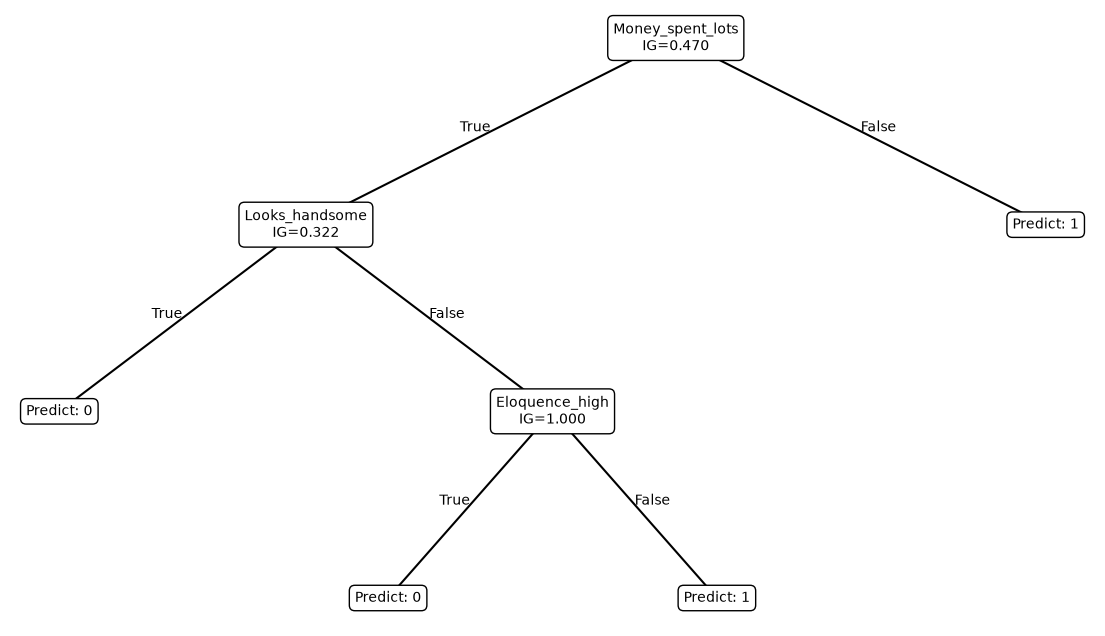

In [61]:
my_tree = build_tree(df_train, y, max_depth=3)

plot_custom_tree(my_tree)

In [63]:
# for Jupyter-book, we copy data from GitHub, locally, to save Internet traffic,
# you can specify the data/ folder from the root of your cloned
# https://github.com/Yorko/mlcourse.ai repo, to save Internet traffic
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

In [64]:
data_train = pd.read_csv(DATA_PATH + "adult_train.csv", sep=";")


In [65]:
data_train.tail()


,Age,Workclass,fnlwgt,Education,Education_Num,Martial_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_per_week,Country,Target
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [68]:
data_test = pd.read_csv(DATA_PATH + "adult_test.csv", sep=";")


In [69]:
data_test.tail()


,Age,Workclass,fnlwgt,Education,Education_Num,Martial_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_per_week,Country,Target
16277,39,Private,215419.0,Bachelors,13.0,Divorced,Prof-specialty,Not-in-family,White,Female,0.0,0.0,36.0,United-States,<=50K.
16278,64,NaN,321403.0,HS-grad,9.0,Widowed,NaN,Other-relative,Black,Male,0.0,0.0,40.0,United-States,<=50K.
16279,38,Private,374983.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K.
16280,44,Private,83891.0,Bachelors,13.0,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455.0,0.0,40.0,United-States,<=50K.
16281,35,Self-emp-inc,182148.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,60.0,United-States,>50K.


In [71]:
data_train["Target"] = data_train["Target"].str.strip().str.replace(".", "", regex=False)
data_test["Target"] = data_test["Target"].str.strip().str.replace(".", "", regex=False)

data_test = data_test[
    data_test["Target"].isin(["<=50K", ">50K"])
].copy()

data_train["Target"] = data_train["Target"].map({
    "<=50K": 0,
    ">50K": 1
})

data_test["Target"] = data_test["Target"].map({
    "<=50K": 0,
    ">50K": 1
})

In [72]:
data_test.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,16281,73,35,461,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Workclass,15318,8,Private,11210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,16281.0,NaN,NaN,NaN,189435.677784,105714.907671,13492.0,116736.0,177831.0,238384.0,1490400.0
Education,16281,16,HS-grad,5283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Num,16281.0,NaN,NaN,NaN,10.072907,2.567545,1.0,9.0,10.0,12.0,16.0
Martial_Status,16281,7,Married-civ-spouse,7403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,15315,14,Prof-specialty,2032,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Relationship,16281,6,Husband,6523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Race,16281,5,White,13946,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,16281,2,Male,10860,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [73]:
data_train["Target"].value_counts()


Target
0    24720
1     7841
Name: count, dtype: int64

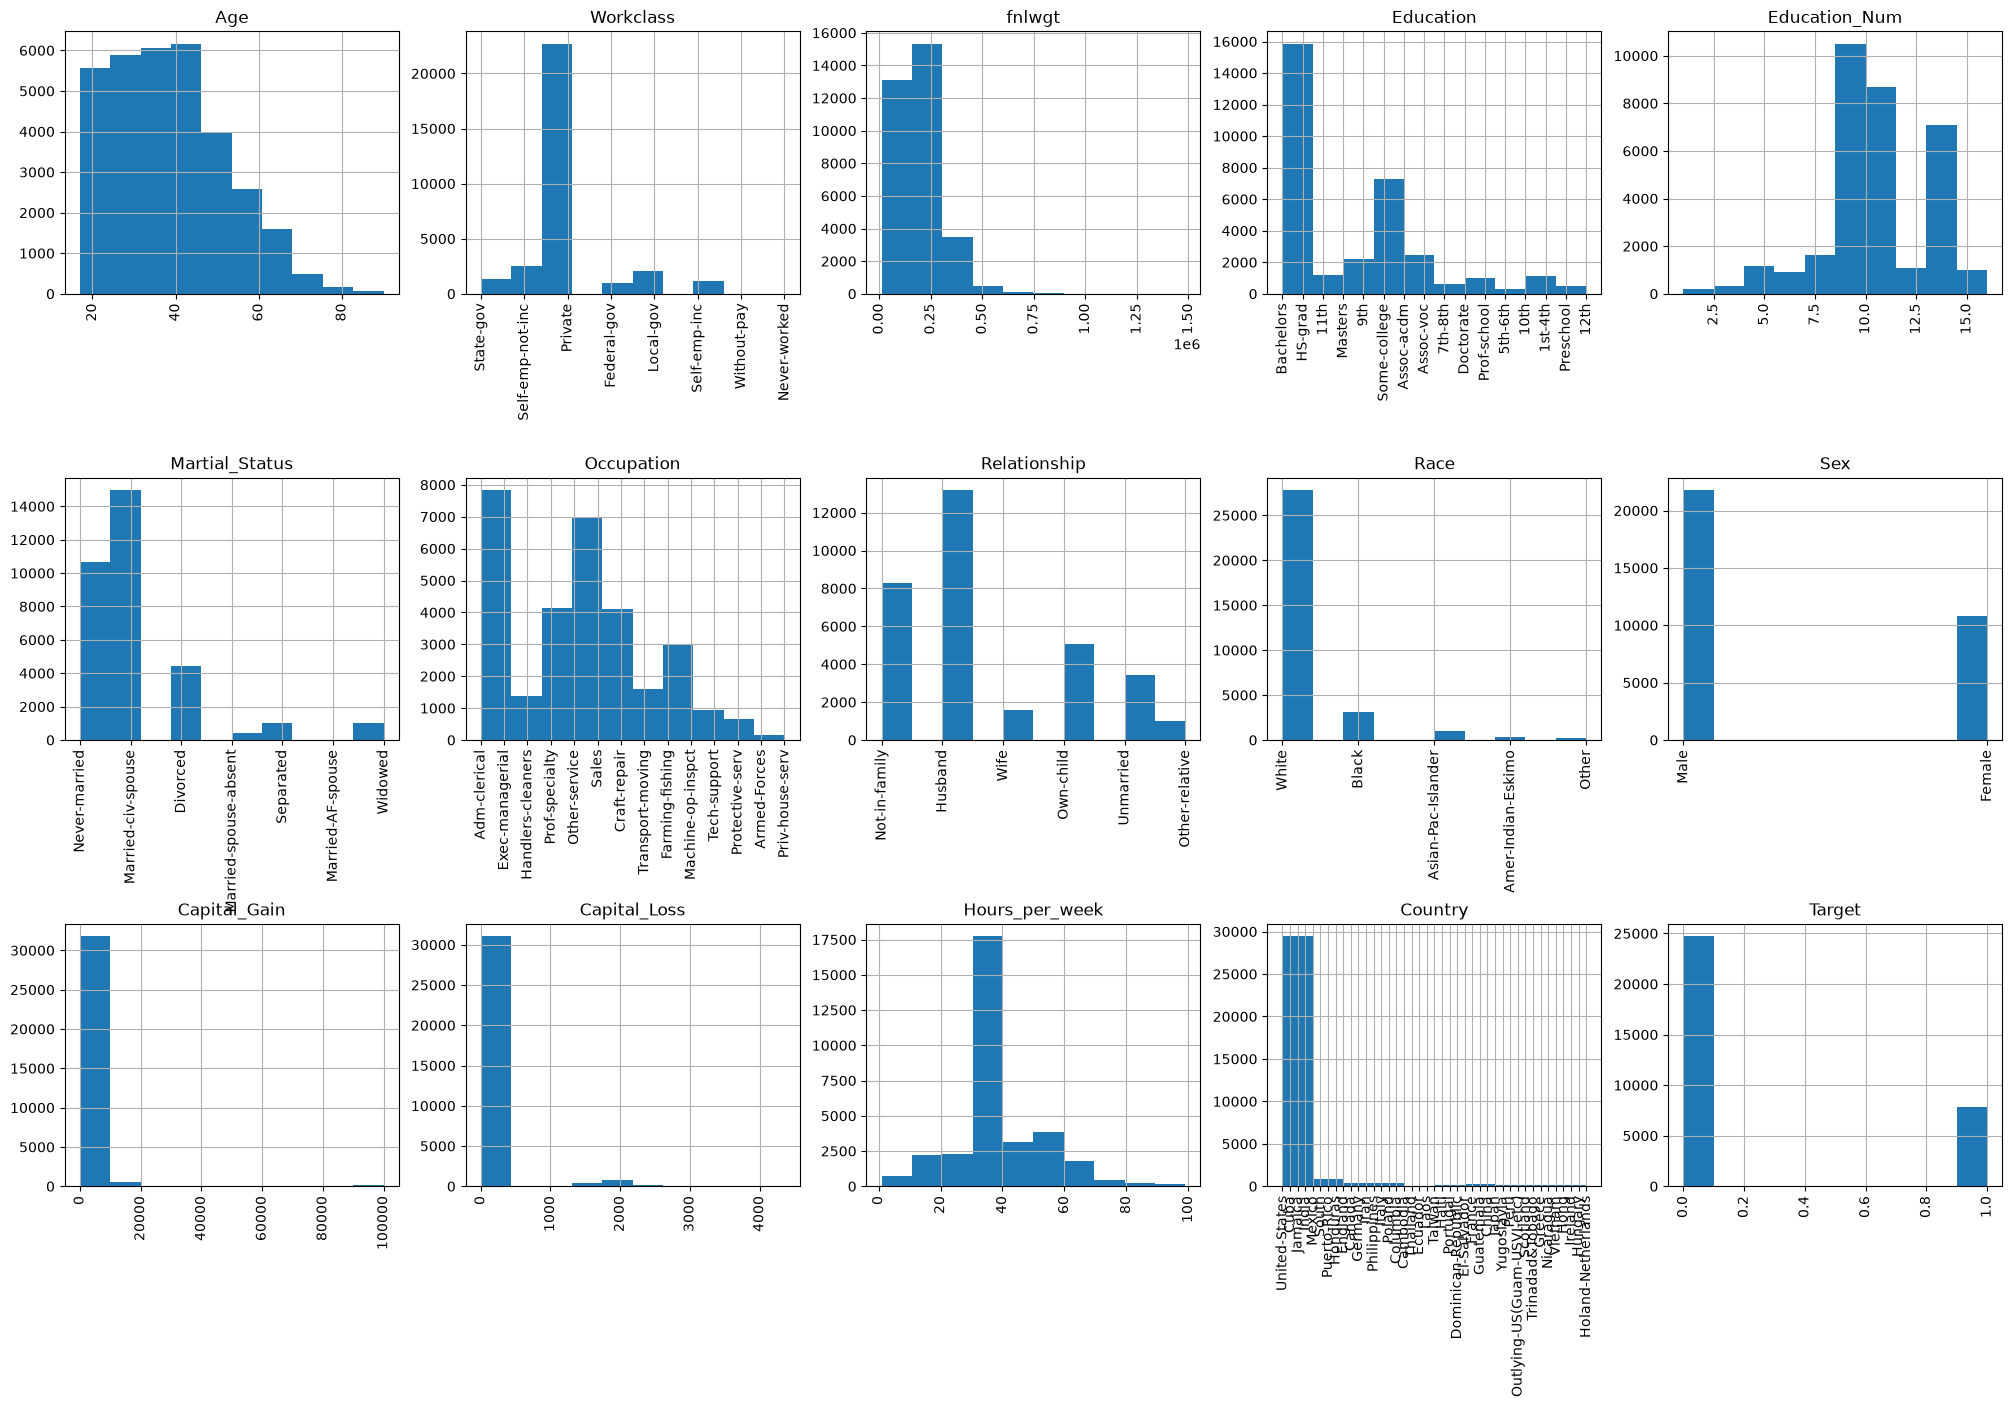

In [74]:
fig = plt.figure(figsize=(25, 15))
cols = 5
rows = int(data_train.shape[1] / cols)
for i, column in enumerate(data_train.columns):
    ax = fig.add_subplot(rows, cols, i + 1)
    ax.set_title(column)
    if data_train.dtypes[column] == object:
        data_train[column].value_counts().plot(kind="bar", axes=ax)
    else:
        data_train[column].hist(axes=ax)
        plt.xticks(rotation="vertical")
plt.subplots_adjust(hspace=0.7, wspace=0.2);

In [75]:
data_train.dtypes


Age               int64
Workclass           str
fnlwgt            int64
Education           str
Education_Num     int64
Martial_Status      str
Occupation          str
Relationship        str
Race                str
Sex                 str
Capital_Gain      int64
Capital_Loss      int64
Hours_per_week    int64
Country             str
Target            int64
dtype: object

In [76]:
data_test.dtypes


Age                   str
Workclass             str
fnlwgt            float64
Education             str
Education_Num     float64
Martial_Status        str
Occupation            str
Relationship          str
Race                  str
Sex                   str
Capital_Gain      float64
Capital_Loss      float64
Hours_per_week    float64
Country               str
Target              int64
dtype: object

In [77]:
data_test["Age"] = data_test["Age"].astype(int)


In [78]:
data_test["fnlwgt"] = data_test["fnlwgt"].astype(int)
data_test["Education_Num"] = data_test["Education_Num"].astype(int)
data_test["Capital_Gain"] = data_test["Capital_Gain"].astype(int)
data_test["Capital_Loss"] = data_test["Capital_Loss"].astype(int)
data_test["Hours_per_week"] = data_test["Hours_per_week"].astype(int)

In [79]:
y_train = data_train.pop('Target')
y_test = data_test.pop('Target')

Fill in missing data for continuous features with their median values, for categorical features with their mode.

In [81]:
from pandas.api.types import is_numeric_dtype

# Целевая переменная — не признак
target_column = "Target"

# Числовые колонки по смыслу датасета Adult
numeric_features = [
    "Age",
    "fnlwgt",
    "Education_Num",
    "Capital_Gain",
    "Capital_Loss",
    "Hours_per_week"
]

# Приводим числовые колонки к числовому типу и в train, и в test
for col in numeric_features:
    data_train[col] = pd.to_numeric(data_train[col], errors="coerce")
    data_test[col] = pd.to_numeric(data_test[col], errors="coerce")

# Все остальные признаки, кроме Target, считаем категориальными
feature_columns = [c for c in data_train.columns if c != target_column]

categorical_columns = [
    c for c in feature_columns if c not in numeric_features
]

numerical_columns = [
    c for c in feature_columns if c in numeric_features
]

print("categorical_columns:", categorical_columns)
print("numerical_columns:", numerical_columns)

categorical_columns: ['Workclass', 'Education', 'Martial_Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Country']
numerical_columns: ['Age', 'fnlwgt', 'Education_Num', 'Capital_Gain', 'Capital_Loss', 'Hours_per_week']


In [82]:
# we see some missing values
data_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             32561 non-null  int64
 1   Workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   Education       32561 non-null  str  
 4   Education_Num   32561 non-null  int64
 5   Martial_Status  32561 non-null  str  
 6   Occupation      30718 non-null  str  
 7   Relationship    32561 non-null  str  
 8   Race            32561 non-null  str  
 9   Sex             32561 non-null  str  
 10  Capital_Gain    32561 non-null  int64
 11  Capital_Loss    32561 non-null  int64
 12  Hours_per_week  32561 non-null  int64
 13  Country         31978 non-null  str  
dtypes: int64(6), str(8)
memory usage: 3.5 MB


In [84]:
for c in categorical_columns:
    fill_value = data_train[c].mode().iloc[0]

    data_train[c] = data_train[c].fillna(fill_value)
    data_test[c] = data_test[c].fillna(fill_value)

for c in numerical_columns:
    fill_value = data_train[c].median()

    data_train[c] = data_train[c].fillna(fill_value)
    data_test[c] = data_test[c].fillna(fill_value)

In [85]:
data_train = pd.concat(
    [data_train[numerical_columns], pd.get_dummies(data_train[categorical_columns])],
    axis=1,
)

data_test = pd.concat(
    [data_test[numerical_columns], pd.get_dummies(data_test[categorical_columns])],
    axis=1,
)

In [86]:
set(data_train.columns) - set(data_test.columns)


{'Country_ Holand-Netherlands'}

In [87]:
data_train.shape, data_test.shape


((32561, 105), (16281, 104))

In [88]:
data_test["Country_ Holand-Netherlands"] = 0


In [89]:
set(data_train.columns) - set(data_test.columns)


set()

In [90]:
data_train.head(2)


,Age,fnlwgt,Education_Num,Capital_Gain,Capital_Loss,Hours_per_week,Workclass_ Federal-gov,Workclass_ Local-gov,Workclass_ Never-worked,Workclass_ Private,...,Country_ Portugal,Country_ Puerto-Rico,Country_ Scotland,Country_ South,Country_ Taiwan,Country_ Thailand,Country_ Trinadad&Tobago,Country_ United-States,Country_ Vietnam,Country_ Yugoslavia
0,39,77516,13,2174,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,0,0,13,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [91]:
X_train = data_train
X_test = data_test

#### 3.1 Decision tree without parameter tuning

Train a decision tree (DecisionTreeClassifier) with a maximum depth of 3, and evaluate the accuracy metric on the test data. Use parameter random_state = 17 for results reproducibility.

In [93]:
tree = DecisionTreeClassifier(max_depth=3, random_state=17)
tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",17
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

Make a prediction with the trained model on the test data.

In [100]:
X_test = X_test[X_train.columns]
tree_prediction = tree.predict(X_test)

6. What is the test set accuracy of a decision tree with maximum tree depth of 3 and random_state = 17?

In [101]:
accuracy_score(y_test, tree_prediction)

0.8447884036607088

#### 3.2 Decision tree with parameter tuning

Train a decision tree (DecisionTreeClassifier, random_state = 17). Find the optimal maximum depth using 5-fold cross-validation (GridSearchCV).

In [105]:
tree_params = {"max_depth": range(2, 11)}

locally_best_tree = GridSearchCV(param_grid=tree_params, estimator=tree, cv=5)  # You code here (read-only in a JupyterBook, pls run jupyter-notebook to edit)

locally_best_tree.fit(X_train, y_train)
# You code here (read-only in a JupyterBook, pls run jupyter-notebook to edit)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=17)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(2, 11)}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with hi

Train a decision tree with maximum depth of 9 (it is the best max_depth in my case), and compute the test set accuracy. Use parameter random_state = 17 for reproducibility.

In [108]:
locally_best_tree.best_params_, locally_best_tree.best_score_

({'max_depth': 9}, np.float64(0.8565770273854106))

7. What is the test set accuracy of a decision tree with maximum depth of 9 and random_state = 17?

In [109]:
# You code here (read-only in a JupyterBook, pls run jupyter-notebook to edit)
tuned_tree = DecisionTreeClassifier(max_depth=9, random_state=17)
tuned_tree.fit(X_train, y_train)
tuned_tree_predictions = tuned_tree.predict(X_test)
accuracy_score(y_test, tuned_tree_predictions)

0.8579939807137154

#### 3.3 (Optional) Random forest without parameter tuning

Train a random forest (RandomForestClassifier). Set the number of trees to 100 and use random_state = 17.

In [113]:
# You code here (read-only in a JupyterBook, pls run jupyter-notebook to edit)
rf = RandomForestClassifier(n_estimators=100, random_state=17, n_jobs=-1)
rf.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",17
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

Make predictions for the test data and assess accuracy.



In [114]:
rf_predictions = rf.predict(X_test)
accuracy_score(y_test, rf_predictions)

0.8525274860266568

#### 3.4 (Optional) Random forest with parameter tuning

Train a random forest (RandomForestClassifier). Tune the maximum depth and maximum number of features for each tree using GridSearchCV.

In [115]:
forest_params = {'max_depth': range(10, 21),
                 'max_features': range(5, 45, 5)}

locally_best_forest = GridSearchCV(param_grid=forest_params, cv=5, estimator=rf, verbose=1, n_jobs=-1)

locally_best_forest.fit(X_train, y_train)

Fitting 5 folds for each of 88 candidates, totalling 440 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=17)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(10, 21), 'max_features': range(5, 45, 5)}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to de

In [116]:
locally_best_forest.best_params_, locally_best_forest.best_score_

({'max_depth': 16, 'max_features': 30}, np.float64(0.8652991833381055))

In [117]:
tuned_tree = DecisionTreeClassifier(max_depth=16, max_features=30, random_state=17)
tuned_tree.fit(X_train, y_train)
tuned_tree_predictions = tuned_tree.predict(X_test)
accuracy_score(y_test, tuned_tree_predictions)

0.8457097229899884